In [ ]:
!pip install torchmetrics

In [ ]:
import torch
from torch import nn, optim
from PIL import Image
from torchvision import transforms
from torchvision.utils import save_image
from google.colab import files
import matplotlib.pyplot as plt
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

In [ ]:
class VariationalAutoEncoder(nn.Module):
    def __init__(self, z_dim=64, message_dim=16, encoder_channels=[3, 64, 128, 256], hidden_dim=1024):
        super().__init__()

        self.z_dim = z_dim
        self.message_dim = message_dim
        self.hidden_dim = hidden_dim
        self.encoder_channels = encoder_channels
        self.decoder_channels = encoder_channels[::-1]

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        # Encoder
        self.encoder_layers = nn.ModuleList()

        for i in range(len(self.encoder_channels) - 1):
            in_ch = self.encoder_channels[i]
            out_ch = self.encoder_channels[i + 1]

            if i < 2:
                self.encoder_layers.append(
                    nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1)
                )
            else:
                self.encoder_layers.append(
                    nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1)
                )

        self.final_channels = self.encoder_channels[-1]
        self.feature_map_size = 16

        flattened_dim = self.final_channels * self.feature_map_size * self.feature_map_size

        self.img2hidden = nn.Linear(flattened_dim, hidden_dim)
        self.hidden2mu = nn.Linear(hidden_dim, z_dim)
        self.hidden2logvar = nn.Linear(hidden_dim, z_dim)

        # Decoder now takes latent vector + message bits
        self.zmsg2hidden = nn.Linear(z_dim + message_dim, hidden_dim)
        self.hidden2img = nn.Linear(hidden_dim, flattened_dim)

        self.decoder_layers = nn.ModuleList()
        num_decoder_layers = len(self.decoder_channels) - 1

        for i in range(num_decoder_layers):
            in_ch = self.decoder_channels[i]
            out_ch = self.decoder_channels[i + 1]

            if i < num_decoder_layers - 2:
                self.decoder_layers.append(
                    nn.ConvTranspose2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1)
                )
            else:
                self.decoder_layers.append(
                    nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1)
                )

        # Revealer: tries to recover message from stego image
        self.revealer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, message_dim)
        )

    def encode(self, x):
        h = x

        for layer in self.encoder_layers:
            h = self.relu(layer(h))

        h = h.reshape(h.size(0), -1)
        h = self.relu(self.img2hidden(h))

        mu = self.hidden2mu(h)
        logvar = self.hidden2logvar(h)

        return mu, logvar

    def decode(self, z, message):
        z_message = torch.cat([z, message], dim=1)

        h = self.relu(self.zmsg2hidden(z_message))
        h = self.relu(self.hidden2img(h))

        h = h.reshape(
            z.size(0),
            self.final_channels,
            self.feature_map_size,
            self.feature_map_size
        )

        for i, layer in enumerate(self.decoder_layers):
            h = layer(h)

            if i < len(self.decoder_layers) - 1:
                h = self.relu(h)
            else:
                h = self.sigmoid(h)

        return h

    def reveal(self, stego_image):
        return self.revealer(stego_image)

    def forward(self, x, message):
        mu, logvar = self.encode(x)

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps

        stego_image = self.decode(z, message)
        predicted_message = self.reveal(stego_image)

        return stego_image, predicted_message, mu, logvar

In [ ]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)

Saving imresizer-Pidgeon ~ ~ ~ #pixelart #pokemon #pidgeon #aseprite #digitalart #digitalartwork #pixelartwork #pixelartist #pixels #pixel #art #ドット絵.jpg to imresizer-Pidgeon ~ ~ ~ #pixelart #pokemon #pidgeon #aseprite #digitalart #digitalartwork #pixelartwork #pixelartist #pixels #pixel #art #ドット絵 (1).jpg
Uploaded image: imresizer-Pidgeon ~ ~ ~ #pixelart #pokemon #pidgeon #aseprite #digitalart #digitalartwork #pixelartwork #pixelartist #pixels #pixel #art #ドット絵 (1).jpg


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
def text_to_bits(text):
    bits = []

    for char in text:
        binary_char = format(ord(char), "08b")

        for bit in binary_char:
            bits.append(int(bit))

    return bits


def bits_to_text(bits):
    chars = []

    for i in range(0, len(bits), 8):
        byte = bits[i:i+8]

        if len(byte) == 8:
            binary_string = "".join(str(bit) for bit in byte)
            chars.append(chr(int(binary_string, 2)))

    return "".join(chars)


secret_message = "HI"
message_bits = text_to_bits(secret_message)

MESSAGE_DIM = len(message_bits)

message_tensor = torch.tensor(
    message_bits,
    dtype=torch.float32
).unsqueeze(0).to(device)

print("Secret message:", secret_message)
print("Message bits:", message_bits)
print("Message dim:", MESSAGE_DIM)

Secret message: HI
Message bits: [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1]
Message dim: 16


In [ ]:
Z_DIM = 64
LR = 8e-4
NUM_STEPS = 10000

model = VariationalAutoEncoder(
    z_dim=Z_DIM,
    message_dim=MESSAGE_DIM
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1000,
    gamma=0.8
)

image_loss_fn = nn.MSELoss(reduction="sum")
message_loss_fn = nn.BCEWithLogitsLoss()

BETA = 0.0001
MESSAGE_WEIGHT = 10.0



In [ ]:


for step in range(NUM_STEPS):

    optimizer.zero_grad()

    stego_image, predicted_message, mu, logvar = model(x, message_tensor)

    image_loss = image_loss_fn(stego_image, x)

    message_loss = message_loss_fn(predicted_message, message_tensor)

    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    loss = image_loss + MESSAGE_WEIGHT * message_loss + BETA * kl

    loss.backward()
    optimizer.step()
    scheduler.step()

    if step % 200 == 0:
        predicted_bits = (torch.sigmoid(predicted_message) > 0.5).int().detach().cpu().tolist()[0]
        recovered_text = bits_to_text(predicted_bits)

        print(
            f"Step {step}: "
            f"total={loss.item():.4f}, "
            f"image={image_loss.item():.4f}, "
            f"message={message_loss.item():.4f}, "
            f"recovered='{recovered_text}'"
        )

print("Training finished.")

Step 0: total=242.0279, image=235.1284, message=0.6900, recovered='T'
Step 200: total=4.6715, image=4.6698, message=0.0000, recovered='HI'
Step 400: total=0.3895, image=0.3831, message=0.0000, recovered='HI'
Step 600: total=0.0892, image=0.0795, message=0.0000, recovered='HI'
Step 800: total=0.0703, image=0.0590, message=0.0000, recovered='HI'
Step 1000: total=0.1261, image=0.1134, message=0.0000, recovered='HI'
Step 1200: total=0.0888, image=0.0753, message=0.0000, recovered='HI'
Step 1400: total=0.1159, image=0.1020, message=0.0000, recovered='HI'
Step 1600: total=0.0225, image=0.0085, message=0.0000, recovered='HI'
Step 1800: total=0.0353, image=0.0215, message=0.0000, recovered='HI'
Step 2000: total=0.0421, image=0.0284, message=0.0000, recovered='HI'
Step 2200: total=0.0445, image=0.0311, message=0.0000, recovered='HI'
Step 2400: total=0.0607, image=0.0479, message=0.0000, recovered='HI'
Step 2600: total=0.1003, image=0.0880, message=0.0000, recovered='HI'
Step 2800: total=0.0359

In [ ]:
model.eval()

with torch.no_grad():
    mu, logvar = model.encode(x)

    zero_message = torch.zeros_like(message_tensor)

    normal_reconstruction = model.decode(mu, zero_message)

    stego_image = model.decode(mu, message_tensor)

    predicted_message = model.reveal(stego_image)

    predicted_bits = (torch.sigmoid(predicted_message) > 0.5).int().cpu().tolist()[0]

    extracted_message = bits_to_text(predicted_bits)

print("Extracted message:", extracted_message)

Extracted message: HI


Images saved separately.


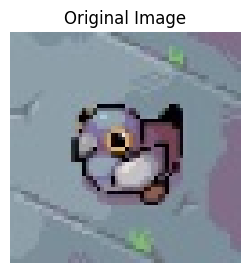

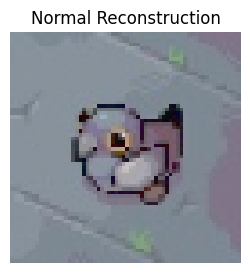

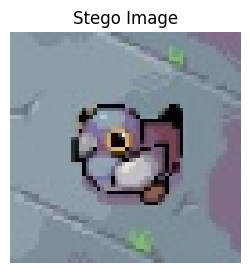

In [ ]:
save_image(x.detach().cpu(), "original_image.png")
save_image(normal_reconstruction.detach().cpu(), "normal_reconstruction.png")
save_image(stego_image.detach().cpu(), "stego_image.png")

print("Images saved separately.")

images = [
    ("Original Image", x),
    ("Normal Reconstruction", normal_reconstruction),
    ("Stego Image", stego_image)
]

for title, image in images:
    image_cpu = image.detach().cpu().squeeze(0)
    image_cpu = image_cpu.permute(1, 2, 0)

    plt.figure(figsize=(3, 3))
    plt.imshow(image_cpu)
    plt.axis("off")
    plt.title(title)
    plt.show()

In [ ]:
print("Original message:", secret_message)
print("Extracted message:", extracted_message)

Original message: HI
Extracted message: HI


In [ ]:
from google.colab import files

files.download("original_image.png")
files.download("normal_reconstruction.png")
files.download("stego_image.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
psnr = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

psnr_normal = psnr(normal_reconstruction, x)
ssim_normal = ssim(normal_reconstruction, x)

psnr_stego = psnr(stego_image, x)
ssim_stego = ssim(stego_image, x)

print("Normal Reconstruction")
print("PSNR:", psnr_normal.item())
print("SSIM:", ssim_normal.item())

print("\nStego Image")
print("PSNR:", psnr_stego.item())
print("SSIM:", ssim_stego.item())

Normal Reconstruction
PSNR: 27.49618148803711
SSIM: 0.94816654920578

Stego Image
PSNR: 58.7413330078125
SSIM: 0.9999245405197144
